In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("data.csv")

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [3]:
print("Shape:", df.shape)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistics")
display(df.describe())

Shape: (4600, 18)

Data Types
date              object
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street            object
city              object
statezip          object
country           object
dtype: object

Missing Values
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

Statistics


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


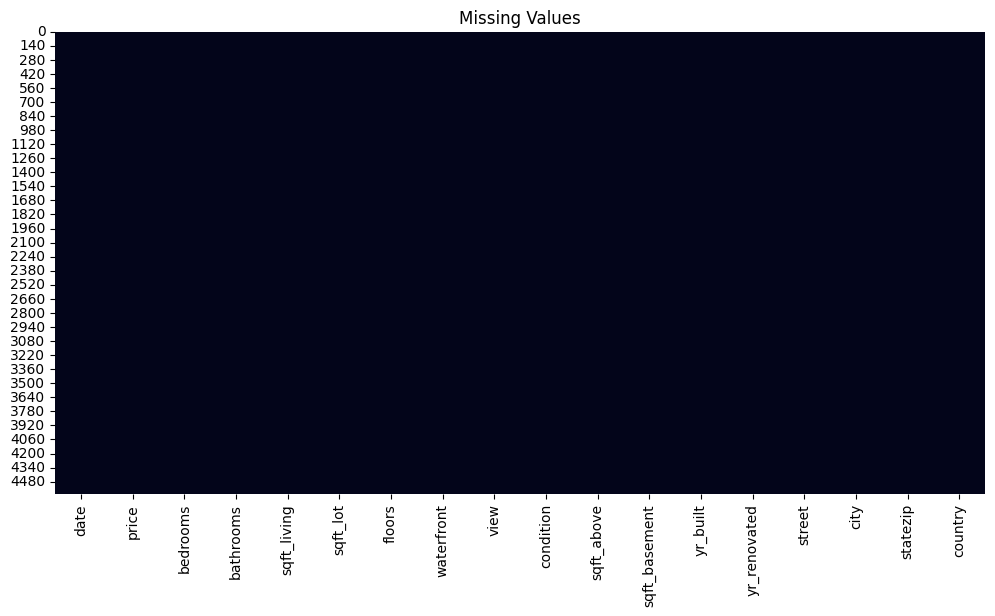

In [4]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values")
plt.show()

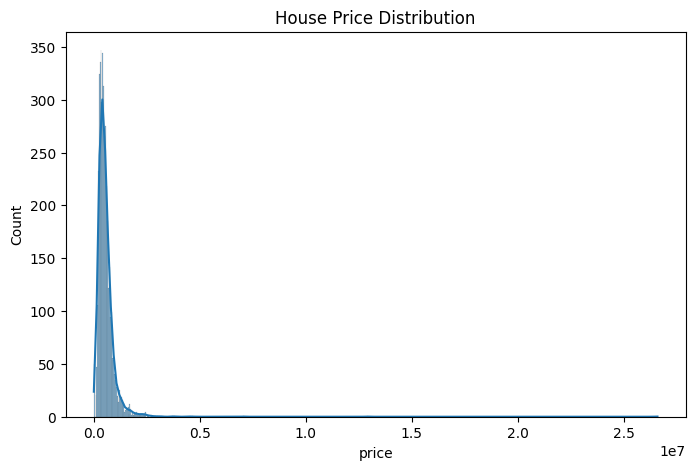

In [5]:
target = "price"

plt.figure(figsize=(8,5))

sns.histplot(
    df[target],
    kde=True
)

plt.title("House Price Distribution")
plt.show()

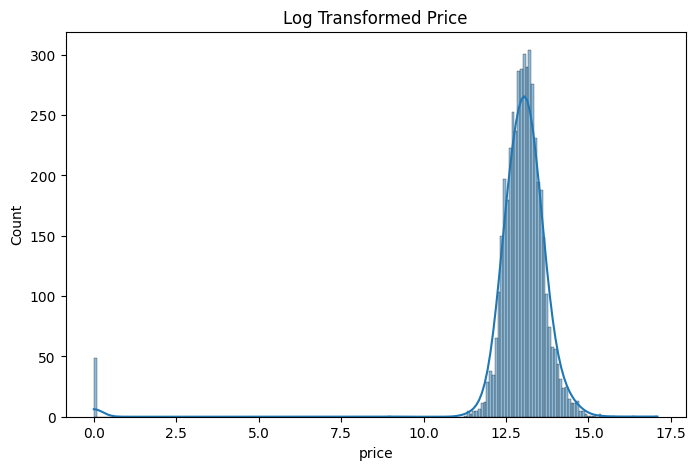

In [6]:
df[target] = np.log1p(df[target])

plt.figure(figsize=(8,5))

sns.histplot(
    df[target],
    kde=True
)

plt.title("Log Transformed Price")
plt.show()

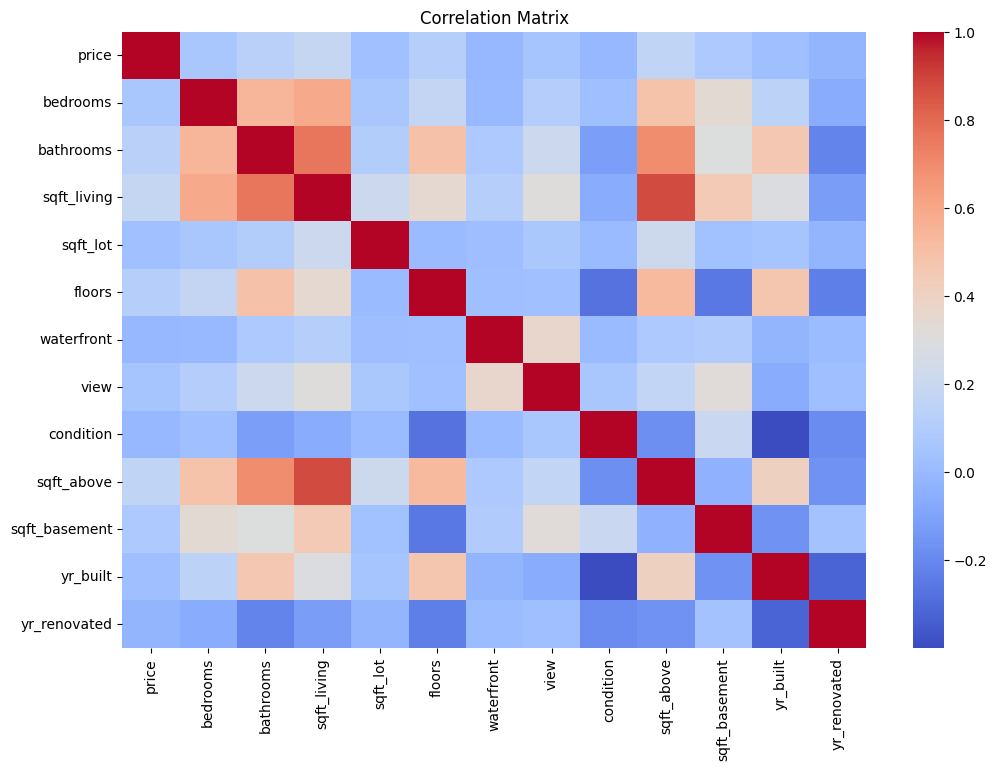

In [7]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [8]:
X = df.drop(target, axis=1)
y = df[target]

In [9]:
numeric_features = X.select_dtypes(
    include=['int64','float64']
).columns

categorical_features = X.select_dtypes(
    include=['object']
).columns

print("Numerical Features:")
print(list(numeric_features))

print("\nCategorical Features:")
print(list(categorical_features))

Numerical Features:
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated']

Categorical Features:
['date', 'street', 'city', 'statezip', 'country']


In [10]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
models = {

    "Linear Regression":
    Pipeline([
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]),

    "Random Forest":
    Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=200,
            random_state=42
        ))
    ]),

    "Gradient Boosting":
    Pipeline([
        ('preprocessor', preprocessor),
        ('model', GradientBoostingRegressor(
            n_estimators=200,
            random_state=42
        ))
    ])
}

In [13]:
results = []

best_model = None
best_rmse = np.inf
best_model_name = ""

for name, model in models.items():

    print("="*60)
    print(name)

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append([
        name,
        rmse,
        mae,
        r2
    ])

    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R²  :", r2)

    if rmse < best_rmse:
        best_rmse = rmse
        best_model = model
        best_model_name = name

Linear Regression
RMSE: 1.3895283807130512
MAE : 0.43700999639773597
R²  : 0.014977914519726854
Random Forest
RMSE: 1.395634290871148
MAE : 0.33197100191702117
R²  : 0.006302063202369257
Gradient Boosting
RMSE: 1.4021924685109233
MAE : 0.41499883896828094
R²  : -0.0030587832328043962


In [14]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "RMSE",
        "MAE",
        "R2"
    ]
)

results_df.sort_values(
    by="RMSE",
    inplace=True
)

results_df

,Model,RMSE,MAE,R2
0,Linear Regression,1.389528,0.437010,0.014978
1,Random Forest,1.395634,0.331971,0.006302
2,Gradient Boosting,1.402192,0.414999,-0.003059


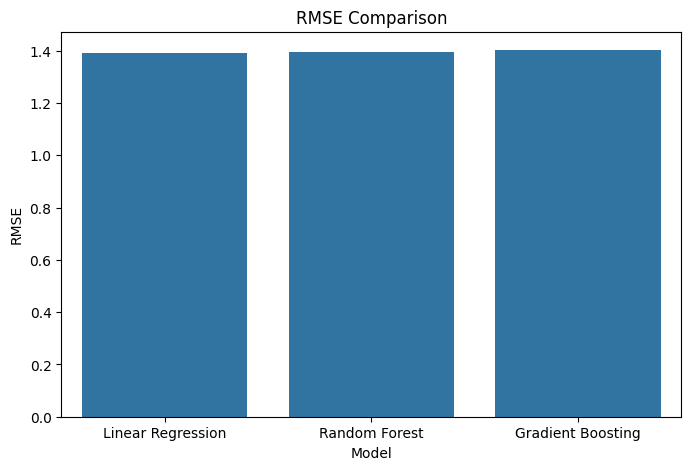

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x='Model',
    y='RMSE'
)

plt.title("RMSE Comparison")
plt.show()

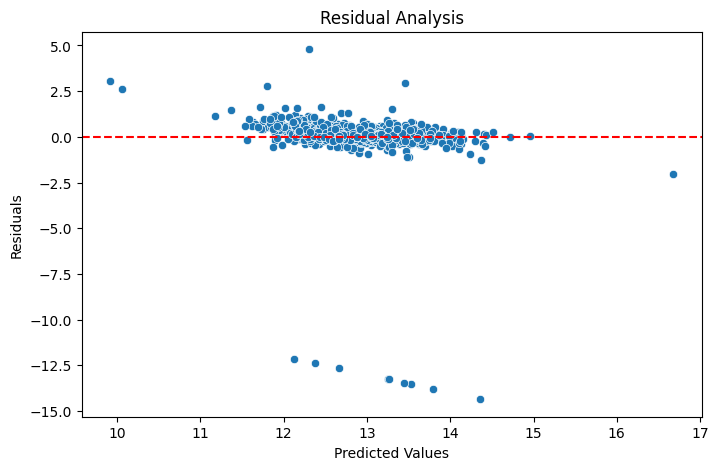

In [16]:
best_predictions = best_model.predict(X_test)

residuals = y_test - best_predictions

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=best_predictions,
    y=residuals
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Analysis")
plt.show()

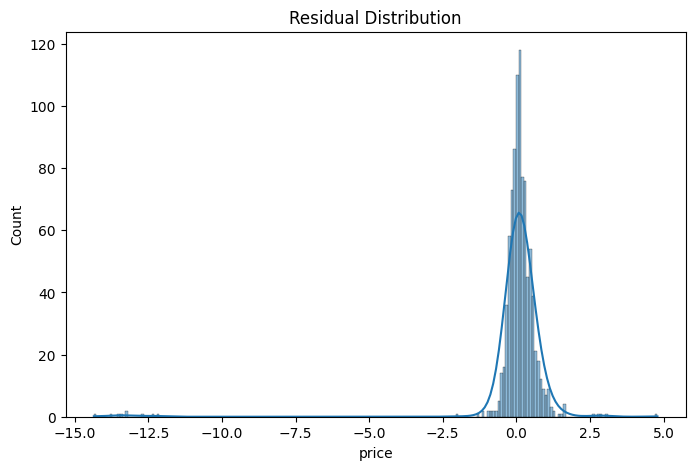

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")
plt.show()

In [18]:
print("Best Model:", best_model_name)

joblib.dump(
    best_model,
    "house_price_model.joblib"
)

print("Model Saved Successfully")

Best Model: Linear Regression
Model Saved Successfully


In [19]:
loaded_model = joblib.load(
    "house_price_model.joblib"
)

In [20]:
sample = X.iloc[[0]]

prediction = loaded_model.predict(sample)

actual_price = np.expm1(y.iloc[0])
predicted_price = np.expm1(prediction[0])

print("Actual Price:", actual_price)
print("Predicted Price:", predicted_price)

Actual Price: 312999.9999999999
Predicted Price: 313047.55880652583
